# MedlinePlus Glossary EDA - FaithfulMed (Google 2D)

Owner: Joao | September milestone, Task #1

**What this notebook is for.** The MedlinePlus glossary is our RAG knowledge base: the
thing the Simplifier retrieves from when it needs a plain-language way to say a medical
term. It is not evaluation data. So this EDA is scoped to three consumers:

1. **Task #4 owners (Renita, Gisele)** - they build the vector index on top of this.
   They need entry counts, text length distribution, and a chunking recommendation.
2. **Simplifier owner** - what the glossary can and cannot define, and how the
   jargon-to-plain-language mapping is structured.
3. **Everyone** - how readable the glossary itself is, which is the ceiling on how
   readable a retrieval-grounded answer can be.

**Output of this notebook:** two CSVs. `medlineplus_topics.csv` (one row per topic, with
the lay summary) and `medlineplus_synonyms.csv` (the surface-form to canonical-topic
lookup). Those are the artifacts Task #4 consumes.

> Source is the NLM bulk Health Topics XML. Field names are confirmed against the real
> file in Section 1, not taken from documentation.

## 0. Setup

In [1]:
!pip install -q textstat pandas matplotlib seaborn lxml


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import re, html, json, collections, io, zipfile, datetime
from pathlib import Path

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import textstat
from lxml import etree

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

### Getting the file

NLM regenerates the bulk XML Tuesday through Saturday and keeps only about the last six
days, so **there is no stable "latest" URL**. We scrape the index page for the newest
dated file rather than hardcoding a date that will 404 next week.

Two things to know before running this:

- `robots.txt` disallows `/xml/` for crawlers. We fetch one specific published file that
  NLM invites you to download, we do not crawl the directory. We set a descriptive
  User-Agent. Do not point a recursive crawler at this path.
- The compressed file is about 4.6 MB and unzips to about 29 MB.

In [3]:
HEADERS = {"User-Agent": "BTT-AIStudio-FaithfulMed-student-research"}

def latest_topics_url():
    """Find the newest dated compressed topics zip on the MedlinePlus XML index page."""
    idx = requests.get("https://medlineplus.gov/xml.html", headers=HEADERS, timeout=60)
    idx.raise_for_status()
    found = re.findall(r"https://medlineplus\.gov/xml/mplus_topics_compressed_(\d{4}-\d{2}-\d{2})\.zip", idx.text)
    if not found:
        raise RuntimeError("No dated topics zip found. Check https://medlineplus.gov/xml.html by hand.")
    newest = max(found)
    return newest, f"https://medlineplus.gov/xml/mplus_topics_compressed_{newest}.zip"

RELEASE_DATE, URL = latest_topics_url()
print("release date:", RELEASE_DATE)

resp = requests.get(URL, headers=HEADERS, timeout=300)
resp.raise_for_status()
raw = resp.content
print(f"downloaded {len(raw):,} bytes")

with zipfile.ZipFile(io.BytesIO(raw)) as z:
    name = [n for n in z.namelist() if n.endswith(".xml")][0]
    xml_bytes = z.read(name)
print(f"{name}: {len(xml_bytes):,} bytes uncompressed")

release date: 2026-09-15


downloaded 4,768,535 bytes
mplus_topics_2026-09-15.xml: 30,091,933 bytes uncompressed


## 1. Schema inventory

Print the real structure before writing analysis code. Everything downstream depends on
getting this right once.

In [4]:
root = etree.fromstring(xml_bytes)
topics = root.findall("health-topic")

print("root attributes:", dict(root.attrib))
print(f"{len(topics)} health-topic elements")

langs = collections.Counter(t.get("language") for t in topics)
print("languages:", dict(langs))

child_counts = collections.Counter()
for t in topics:
    for c in t:
        child_counts[c.tag] += 1

print("\nchild elements across all topics:")
for tag, n in child_counts.most_common():
    print(f"  {tag:24s} {n:,}")

print("\nattributes on health-topic:", sorted({k for t in topics for k in t.attrib}))

root attributes: {'total': '2033', 'date-generated': '09/15/2026 02:07:50'}
2033 health-topic elements
languages: {'English': 1017, 'Spanish': 1016}

child elements across all topics:
  site                     52,857
  related-topic            6,099
  other-language           4,895
  group                    3,643
  see-reference            3,161
  language-mapped-topic    2,032
  full-summary             2,028
  also-called              2,024
  primary-institute        1,619
  mesh-heading             1,358

attributes on health-topic: ['date-created', 'id', 'language', 'meta-desc', 'title', 'url']


**The first thing that matters:** the file is roughly half Spanish. Any count you quote
has to say which language it is about, or it is off by a factor of two.

That is not just a parsing footnote. Spanish generation is a stretch goal in the project
brief, described as the biggest equity win. The glossary already ships a parallel Spanish
corpus, so that stretch goal is cheaper than it looks.

In [5]:
english = [t for t in topics if t.get("language") == "English"]
spanish = [t for t in topics if t.get("language") == "Spanish"]
print(f"English: {len(english)}   Spanish: {len(spanish)}")

mapped = sum(1 for t in english if t.find("language-mapped-topic") is not None)
print(f"English topics with a Spanish counterpart: {mapped}/{len(english)} ({mapped/len(english)*100:.1f}%)")

print("\nOne full record, structure only:")
print(etree.tostring(english[0], pretty_print=True).decode()[:1200])

English: 1017   Spanish: 1016
English topics with a Spanish counterpart: 1016/1017 (99.9%)

One full record, structure only:
<health-topic meta-desc="A1C is a blood test for type 2 diabetes and prediabetes. It measures your average blood glucose, or blood sugar, levels over the past 3 months. Learn more." title="A1C" url="https://medlineplus.gov/a1c.html" id="6308" language="English" date-created="12/22/2015">
<also-called>Glycohemoglobin</also-called>
<also-called>HbA1C</also-called>
<also-called>Hemoglobin A1C test</also-called>
<full-summary>&lt;p&gt;A1C is a blood test for &lt;a href="https://medlineplus.gov/diabetestype2.html"&gt;type 2 diabetes&lt;/a&gt; and &lt;a href="https://medlineplus.gov/prediabetes.html"&gt;prediabetes&lt;/a&gt;. It measures your average blood glucose, or &lt;a href="https://medlineplus.gov/bloodglucose.html"&gt;blood sugar&lt;/a&gt;, level over the past 3 months. Doctors may use the A1C alone or in combination with other diabetes tests to make a diagnosis

### 1b. Text extraction

`full-summary` is HTML escaped inside the XML, so it arrives as a string containing
`&lt;p&gt;` rather than as markup. It has to be unescaped and then stripped, in that
order. Doing only one of the two silently leaves tags in the text, which would inflate
every word count and wreck the readability numbers.

In [6]:
def strip_html(s):
    """Unescape, then remove tags, then collapse whitespace. Order matters."""
    s = html.unescape(s or "")
    s = re.sub(r"<[^>]+>", " ", s)
    return re.sub(r"\s+", " ", s).strip()

_raw = english[0].findtext("full-summary")
print("RAW (first 200 chars):")
print(repr(_raw[:200]))
print("\nCLEANED:")
print(strip_html(_raw)[:300])

RAW (first 200 chars):
'<p>A1C is a blood test for <a href="https://medlineplus.gov/diabetestype2.html">type 2 diabetes</a> and <a href="https://medlineplus.gov/prediabetes.html">prediabetes</a>. It measures your average blo'

CLEANED:
A1C is a blood test for type 2 diabetes and prediabetes . It measures your average blood glucose, or blood sugar , level over the past 3 months. Doctors may use the A1C alone or in combination with other diabetes tests to make a diagnosis. They also use the A1C to see how well you are managing your 


## 2. Topic-level view

One row per English topic. This is the table Task #4 will embed.

In [7]:
rows = []
for t in english:
    summary = strip_html(t.findtext("full-summary"))
    if not summary:
        continue
    words = summary.split()
    rows.append({
        "topic_id": t.get("id"),
        "title": t.get("title"),
        "url": t.get("url"),
        "date_created": t.get("date-created"),
        "summary": summary,
        "n_words": len(words),
        "fk_grade": textstat.flesch_kincaid_grade(summary) if len(words) > 20 else np.nan,
        "n_also_called": len(t.findall("also-called")),
        "n_see_reference": len(t.findall("see-reference")),
        "n_groups": len(t.findall("group")),
        "has_mesh": t.find("mesh-heading") is not None,
        "has_spanish": t.find("language-mapped-topic") is not None,
    })

df = pd.DataFrame(rows)
print(f"{len(df)} topics with a usable summary "
      f"({len(english) - len(df)} English topics had none)")
df[["title", "n_words", "fk_grade", "n_also_called", "has_mesh"]].head()

1012 topics with a usable summary (5 English topics had none)


,title,n_words,fk_grade,n_also_called,has_mesh
0,A1C,197,6.788846,3,True
1,Abdominal Pain,136,7.525294,1,True
2,Abortion,89,9.573182,1,True
3,Abscess,116,7.239969,0,True
4,Acne,167,6.592410,2,True


In [8]:
print(df[["n_words", "fk_grade"]].describe().round(2))

print("\nfield coverage:")
for col, label in [("has_mesh", "has a MeSH heading"),
                   ("has_spanish", "has a Spanish counterpart")]:
    print(f"  {label:32s} {df[col].mean()*100:5.1f}%")
print(f"  {'has >=1 also-called synonym':32s} {(df.n_also_called > 0).mean()*100:5.1f}%")
print(f"  {'has >=1 see-reference':32s} {(df.n_see_reference > 0).mean()*100:5.1f}%")

       n_words  fk_grade
count  1012.00   1012.00
mean    346.25      8.71
std     276.53      1.91
min      33.00      3.03
25%     136.00      7.52
50%     193.00      8.51
75%     550.00      9.58
max    1225.00     23.29

field coverage:
  has a MeSH heading                99.8%
  has a Spanish counterpart         99.9%
  has >=1 also-called synonym       49.7%
  has >=1 see-reference             73.5%


## 3. Summary length - this drives the chunking decision

**The deliverable for Task #4.** Renita and Gisele have to decide whether to embed each
topic as one vector or split it into chunks. That decision comes from this distribution,
so read the percentiles rather than the mean.

summary length in words:
  p10      109
  p25      136
  p50      193
  p75      550
  p90      792
  p95      913
  p99     1052
  max     1225


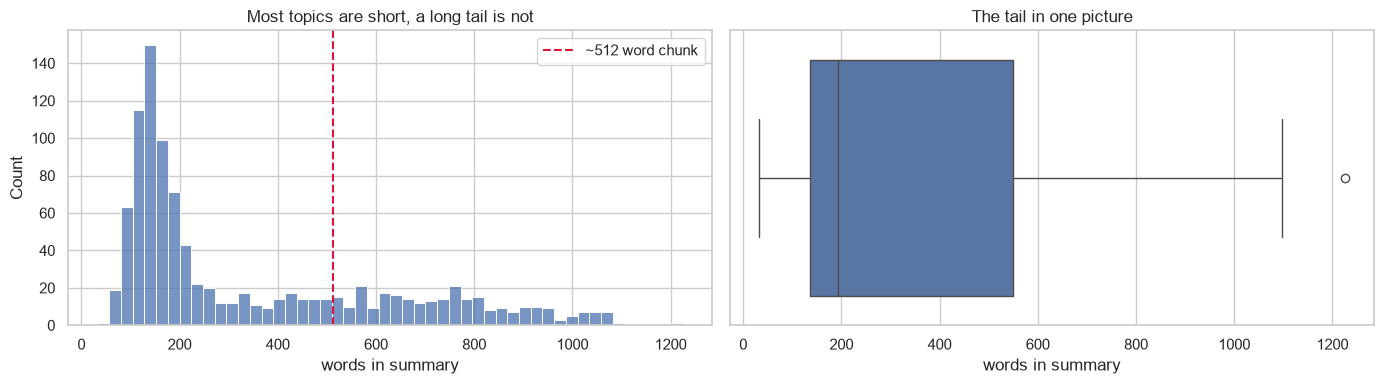


27.2% of topics are longer than ~512 words, so a single-vector-per-topic index would truncate or dilute them.


In [9]:
pcts = [10, 25, 50, 75, 90, 95, 99]
print("summary length in words:")
for p in pcts:
    print(f"  p{p:<3d} {np.percentile(df.n_words, p):7.0f}")
print(f"  max  {df.n_words.max():7.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df.n_words, bins=50, ax=axes[0])
axes[0].axvline(512, color="crimson", ls="--", label="~512 word chunk")
axes[0].set_xlabel("words in summary")
axes[0].set_title("Most topics are short, a long tail is not")
axes[0].legend()

sns.boxplot(x=df.n_words, ax=axes[1])
axes[1].set_xlabel("words in summary")
axes[1].set_title("The tail in one picture")
plt.tight_layout()
plt.show()

over = (df.n_words > 512).mean() * 100
print(f"\n{over:.1f}% of topics are longer than ~512 words, so a single-vector-per-topic "
      f"index would truncate or dilute them.")

## 4. Readability - the ceiling on our output

The project targets 8th grade. The glossary is the text our Simplifier retrieves and
paraphrases from, so **the glossary's own reading level is roughly the ceiling on how
readable a grounded answer can be**. If we retrieve a grade 12 definition and the
Simplifier copies from it, we inherit grade 12.

This is the number to compare against Isha's MedAESQA finding.

n = 1012
mean   8.71
median 8.51
at or below grade 8:  38.0%
at or below grade 10: 81.7%


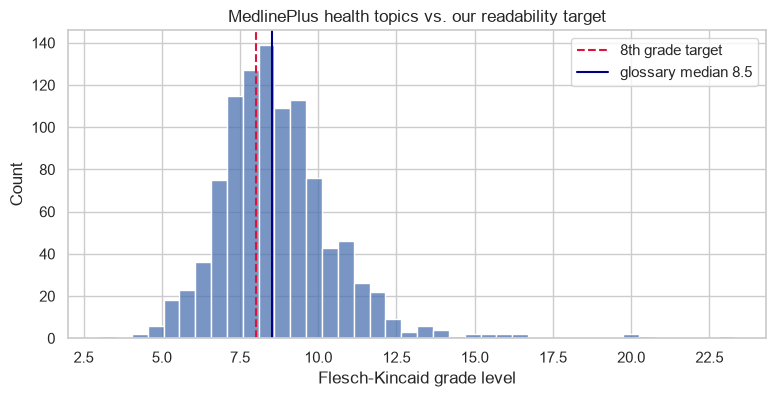

In [10]:
g = df.fk_grade.dropna()

print(f"n = {len(g)}")
print(f"mean   {g.mean():.2f}")
print(f"median {g.median():.2f}")
print(f"at or below grade 8:  {(g <= 8).mean()*100:.1f}%")
print(f"at or below grade 10: {(g <= 10).mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(g, bins=40, ax=ax)
ax.axvline(8, color="crimson", ls="--", label="8th grade target")
ax.axvline(g.median(), color="navy", ls="-", label=f"glossary median {g.median():.1f}")
ax.set_xlabel("Flesch-Kincaid grade level")
ax.set_title("MedlinePlus health topics vs. our readability target")
ax.legend()
plt.show()

In [11]:
easiest = df.nsmallest(8, "fk_grade")[["title", "fk_grade", "n_words"]]
hardest = df.nlargest(8, "fk_grade")[["title", "fk_grade", "n_words"]]
print("EASIEST topics:"); print(easiest.to_string(index=False))
print("\nHARDEST topics:"); print(hardest.to_string(index=False))

EASIEST topics:
                     title  fk_grade  n_words
             Hair Problems  3.028261       89
             Benign Tumors  4.286601      137
              Canker Sores  4.518602      129
                  Dentures  4.680935      205
                     Tears  4.818605       86
                   Choking  4.897955      111
                Cold Sores  4.977159      195
Jaw Injuries and Disorders  4.978297      192

HARDEST topics:
                                   title  fk_grade  n_words
                      Health Disparities 23.292727       88
                              Ergonomics 20.457415      147
                         Penis Disorders 20.227874       92
            Plastic and Cosmetic Surgery 19.800914       93
                                   Edema 16.526000      102
              Winter Weather Emergencies 16.295378      314
Choosing a Doctor or Health Care Service 15.992536       69
                          Rehabilitation 15.754481      474


## 5. The synonym layer - the actual jargon-to-plain-language mapping

This is the most directly useful thing in the file for the Simplifier, and it is easy to
miss if you only look at the summaries.

Two element types carry alternate names for a topic:

- `also-called` - clinical synonyms, e.g. A1C is also called Glycohemoglobin
- `see-reference` - lay and colloquial entry terms, e.g. Zits points to Acne

Flattened, these give a lookup from any surface form a document might use to one
canonical topic that has a plain-language summary. That is a jargon normalizer we get for
free, before any embedding model is involved.

In [12]:
lut = []
for t in english:
    title = t.get("title")
    lut.append({"surface": title, "canonical": title, "kind": "title",
                "canonical_url": t.get("url")})
    for tag, kind in (("also-called", "also_called"), ("see-reference", "see_reference")):
        for a in t.findall(tag):
            if a.text and a.text.strip():
                lut.append({"surface": a.text.strip(), "canonical": title,
                            "kind": kind, "canonical_url": t.get("url")})

synonyms = pd.DataFrame(lut)
dupes = synonyms.surface.str.lower().duplicated().sum()
synonyms = synonyms.loc[~synonyms.surface.str.lower().duplicated(keep="first")].reset_index(drop=True)

print(f"{len(synonyms):,} unique surface forms mapping to {synonyms.canonical.nunique():,} topics")
print(f"({dupes} duplicate surface forms dropped, first occurrence kept)")
print()
print(synonyms.kind.value_counts().to_frame("n"))

2,868 unique surface forms mapping to 1,017 topics
(608 duplicate surface forms dropped, first occurrence kept)

                  n
kind               
title          1017
see_reference   940
also_called     911


In [13]:
print("Sample lay-term entry points (see-reference):")
print(synonyms[synonyms.kind == "see_reference"].head(12)[["surface", "canonical"]].to_string(index=False))
print()
print("Sample clinical synonyms (also-called):")
print(synonyms[synonyms.kind == "also_called"].head(12)[["surface", "canonical"]].to_string(index=False))

Sample lay-term entry points (see-reference):
                      surface                  canonical
               Hemoglobin A1c                        A1C
              Pain, Abdominal             Abdominal Pain
                 Stomach Ache             Abdominal Pain
            Neuroma, Acoustic           Acoustic Neuroma
                   Bronchitis           Acute Bronchitis
Leukemia, Acute Lymphoblastic Acute Lymphocytic Leukemia
  Leukemia, Acute Lymphocytic Acute Lymphocytic Leukemia
  Acute Myeloblastic Leukemia     Acute Myeloid Leukemia
Leukemia, Myeloblastic, Acute     Acute Myeloid Leukemia
 Leukemia, Myelogenous, Acute     Acute Myeloid Leukemia
     Leukemia, Myeloid, Acute     Acute Myeloid Leukemia
        Adrenal Insufficiency            Addison Disease

Sample clinical synonyms (also-called):
              surface        canonical
      Glycohemoglobin              A1C
                HbA1C              A1C
  Hemoglobin A1C test              A1C
            Bell

### 5b. Coverage test - what the glossary actually defines

A synonym table is only useful if it covers the words our source documents actually
contain. MTSamples reports and Synthea records are full of drug names, lab values and
procedures, so test against those rather than against topic titles we already know are
present.

This is the finding most likely to change someone's plan, so run it before Task #4 is
built rather than after.

In [14]:
CLINICAL_TERMS = {
    "conditions": ["hypertension", "myocardial infarction", "COPD", "atrial fibrillation",
                   "hyperlipidemia", "pneumonia", "anemia", "GERD", "osteoporosis",
                   "hypothyroidism", "cellulitis", "sepsis", "DVT"],
    "symptoms":   ["dyspnea", "edema", "tachycardia"],
    "drugs":      ["beta-blocker", "metformin", "warfarin", "statin", "NSAID"],
    "labs":       ["CBC", "HbA1c", "creatinine", "troponin"],
    "procedures": ["echocardiogram", "colonoscopy", "biopsy", "stent", "catheter"],
}

keys = set(synonyms.surface.str.lower())

results = []
for category, terms in CLINICAL_TERMS.items():
    for term in terms:
        results.append({"category": category, "term": term, "found": term.lower() in keys})
cov = pd.DataFrame(results)

by_cat = (cov.groupby("category")
            .agg(n=("term", "size"), found=("found", "sum"))
            .assign(pct=lambda d: (d.found / d.n * 100).round(0))
            .sort_values("pct", ascending=False))
print(by_cat.to_string())

# Report the worst category first. The pooled average across categories is
# misleading here: 67% overall sounds acceptable and hides that one whole
# content type scores zero, which is the finding that changes what we build.
worst = by_cat.sort_values("pct").iloc[0]
print(f"\nWORST CATEGORY: {worst.name} -- {int(worst.found)}/{int(worst.n)} found "
      f"({worst.pct:.0f}%)")
print("  not found: " + ", ".join(cov.loc[~cov.found & cov.category.eq(worst.name), "term"]))

zero = by_cat[by_cat.found == 0]
for name, r in zero.iterrows():
    print(f"\n>>> The glossary defines NONE of the {name} tested ({int(r.n)}/{int(r.n)} missing).")
    print("    Discharge summaries are largely medications, so the Simplifier would")
    print("    retrieve nothing and then either refuse or invent an explanation.")

print(f"\n(pooled across all categories: {cov.found.sum()}/{len(cov)} = "
      f"{cov.found.mean()*100:.0f}%, reported second on purpose)")
print("\nALL TERMS NOT FOUND:")
print("  " + ", ".join(cov.loc[~cov.found, "term"]))

             n  found    pct
category                    
conditions  13     13  100.0
symptoms     3      3  100.0
labs         4      2   50.0
procedures   5      2   40.0
drugs        5      0    0.0

WORST CATEGORY: drugs -- 0/5 found (0%)
  not found: beta-blocker, metformin, warfarin, statin, NSAID

>>> The glossary defines NONE of the drugs tested (5/5 missing).
    Discharge summaries are largely medications, so the Simplifier would
    retrieve nothing and then either refuse or invent an explanation.

(pooled across all categories: 20/30 = 67%, reported second on purpose)

ALL TERMS NOT FOUND:
  beta-blocker, metformin, warfarin, statin, NSAID, creatinine, troponin, echocardiogram, stent, catheter


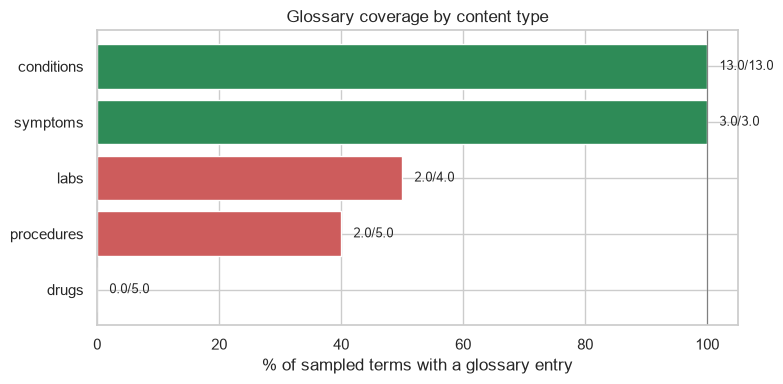

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["seagreen" if p >= 60 else "indianred" for p in by_cat.pct]
ax.barh(by_cat.index, by_cat.pct, color=colors)
ax.axvline(100, color="grey", lw=0.8)
ax.set_xlabel("% of sampled terms with a glossary entry")
ax.set_xlim(0, 105)
ax.set_title("Glossary coverage by content type")
ax.invert_yaxis()
for i, (cat, r) in enumerate(by_cat.iterrows()):
    ax.text(r.pct + 2, i, f"{r.found}/{r.n}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 6. Freeze and export

Same discipline the advisor asked for on MedAESQA. The glossary is a live NLM file that
changes several times a week, so **the release date is part of the result**. Record it, or
a rebuilt index silently stops matching the numbers in the report.

In [16]:
import hashlib

digest = hashlib.sha256(xml_bytes).hexdigest()
print("source release date:", RELEASE_DATE)
print("sha256:", digest)

df.to_csv("medlineplus_topics.csv", index=False)
synonyms.to_csv("medlineplus_synonyms.csv", index=False)

with open("medlineplus_freeze.txt", "w") as f:
    f.write(f"source: mplus_topics_{RELEASE_DATE}.xml\n")
    f.write(f"release_date: {RELEASE_DATE}\n")
    f.write(f"sha256: {digest}\n")
    f.write(f"n_english_topics: {len(df)}\n")
    f.write(f"n_surface_forms: {len(synonyms)}\n")

print("\nwrote medlineplus_topics.csv, medlineplus_synonyms.csv, medlineplus_freeze.txt")

source release date: 2026-09-15
sha256: 35970c9cc955221b720e0768bb49b1b6873147eb73eb4e7116d26b8d07cf6762

wrote medlineplus_topics.csv, medlineplus_synonyms.csv, medlineplus_freeze.txt


## 7. Findings

| # | Finding | Who needs it | Action |
|---|---------|--------------|--------|
| 1 | The file is half Spanish, with a parallel Spanish topic for 99.9% of English topics | everyone | the Spanish stretch goal is much cheaper than it looks |
| 2 | Summaries run 33 to 1,225 words, p75 is 550 | Task #4 | chunk the long tail, do not use one vector per topic |
| 3 | Glossary median is grade 8.5, only 38% at or below grade 8 | Simplifier, Readability | retrieval alone does not hit the target, the Readability agent has real work |
| 4 | 2,868 surface forms map to 1,017 topics, including lay terms like Zits to Acne | Simplifier | a free jargon normalizer, use it before embedding |
| 5 | Zero drug coverage: 0 of 5 medications defined, vs 13 of 13 conditions | Simplifier, Extractor | the glossary cannot define medications, we need a second source |
| 6 | 99.8% of topics carry a MeSH ID | whoever adds a second source | MeSH is the join key to other vocabularies |

**The one that changes a plan:** finding 5. The glossary is a *condition* encyclopedia, not
a drug or lab reference. A discharge summary is mostly drugs, doses and lab values. If the
Simplifier is expected to explain "metformin" or "troponin" from this index, it will
retrieve nothing and either refuse or invent something, and inventing is precisely the
failure mode this whole project exists to prevent.

**Open questions for Ram:**
- We already asked what the other datasets are for if the vector DB is only over
  MedlinePlus. This EDA sharpens that: the glossary has no drug or lab coverage. Should we
  add a second source for medications, and is MedlinePlus Genetics or MeSH acceptable?
- Is it in scope to handle a retrieval miss explicitly, so the Simplifier says a term is
  undefined rather than paraphrasing it unsupported?

**Attribution.** Source: MedlinePlus, National Library of Medicine. Health topic content is
a US federal work and public domain. The A.D.A.M. Medical Encyclopedia on the same site is
separately licensed and must not be ingested.